# House Price Categorization — Classification Models


This notebook explores an alternative framing of the house price prediction problem as a classification task.
Instead of predicting exact prices, properties are categorized into predefined price ranges (e.g. low, medium, high).

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import time
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from scipy.stats import chi2

In [2]:
df_2 = pd.read_csv('../data/processed/df2.csv')

In [3]:
df_2.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,SaleCondition,SalePrice,BsmtFinRatio,LivingAreaPerRoom,AgeAtSale,RemodAge,TotalBath,TotalPorchSF,HouseAge,Remodeled
0,60,3,65.0,8450,3,3,4,0,5,2,...,4,208500,0.500585,213.750000,5,5,3.5,61,5,0
1,20,3,80.0,9600,3,3,2,0,24,1,...,4,181500,1.000000,210.333333,31,31,2.5,298,31,0
2,60,3,68.0,11250,0,3,4,0,5,2,...,4,223500,0.515118,297.666667,7,6,3.5,42,7,1
3,60,3,84.0,14260,0,3,2,0,15,2,...,4,250000,0.520928,244.222222,8,8,3.5,276,8,0
4,50,3,85.0,14115,0,3,4,0,11,2,...,4,143000,0.584435,272.400000,16,14,2.5,70,16,1


## 1. Target Variable Transformation
Machine learning classifiers require discrete target categories. We will convert the continuous `SalePrice` feature into three logical market segments based on quartile thresholds from our previous exploratory data analysis.

In [4]:
# Define price boundaries (bins) based on the SalePrice distribution
# "Low": <= Q1, "Medium": Q1-Q3, "High": > Q3
price_bins = [0, 130000, 215000, np.inf]
price_labels = ["Low", "Medium", "High"]

# Discretize the continuous SalePrice column into 3 distinct categories
df_2["SalePrice_cat"] = pd.cut(
    df_2["SalePrice"],
    bins=price_bins,
    labels=price_labels
)

# Verify the class distribution
# Note: Classes will not be perfectly balanced, which is expected and represents real-world market segments
print(df_2["SalePrice_cat"].value_counts(sort=False))

SalePrice_cat
Low       364
Medium    691
High      310
Name: count, dtype: int64


## 2. Train-Test Split & Target Encoding
Before modeling, we must numerically encode our text-based labels. When splitting the data, we use a **stratified split** to guarantee that the proportions of Low, Medium, and High priced homes are preserved consistently across both the training and testing sets.

In [5]:
# Map text labels to numerical classes for algorithmic compatibility
mapping = {"Low": 0, "Medium": 1, "High": 2}
y = df_2["SalePrice_cat"].map(mapping)

# Drop both the original continuous target and the unmapped categorical column
X = df_2.drop(columns=["SalePrice", "SalePrice_cat"])

# Split the dataset: 80% for training, 20% for testing
# stratify=y ensures the same class balance is maintained in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

## 3. Model Initialization
We define two robust, tree-based classification models: Random Forest and XGBoost. These algorithms natively handle multi-class problems and automatically capture complex, non-linear relationships in tabular data.

In [6]:
# Initialize a dictionary of classification models with conservative baseline hyperparameters
models_clf = {
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=1500,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1  # Utilize all available CPU cores
    ),
    "XGBClassifier": XGBClassifier(
        n_estimators=1500,
        learning_rate=0.05,
        max_depth=6,
        objective="multi:softprob", # Setup for multi-class probability outputs
        num_class=3,                # Specify the 3 target categories
        eval_metric="mlogloss",     # Use multi-class logloss for evaluation
        random_state=42,
        n_jobs=-1
    )
}

## 4. Training, Evaluation & Cross-Validation
We iterate through our models to train them and evaluate their generalization capabilities. 
Because our classes are slightly imbalanced, relying solely on Accuracy is insufficient. We heavily weigh the **F1-Weighted** score, and we plot a **Confusion Matrix** to visualize exactly which specific price tiers our models are confusing.


================ RandomForestClassifier ================

 TRAIN
Accuracy      : 1.0000
F1-weighted   : 1.0000
F1-macro      : 1.0000

 TEST
Accuracy      : 0.8388
F1-weighted   : 0.8390
F1-macro      : 0.8373

CV Robustness (Accuracy): mean=0.8443 | std=0.0257


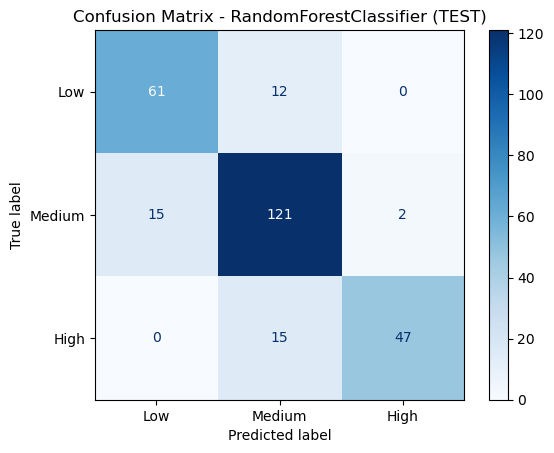


================ XGBClassifier ================

 TRAIN
Accuracy      : 1.0000
F1-weighted   : 1.0000
F1-macro      : 1.0000

 TEST
Accuracy      : 0.8535
F1-weighted   : 0.8537
F1-macro      : 0.8542

CV Robustness (Accuracy): mean=0.8498 | std=0.0222


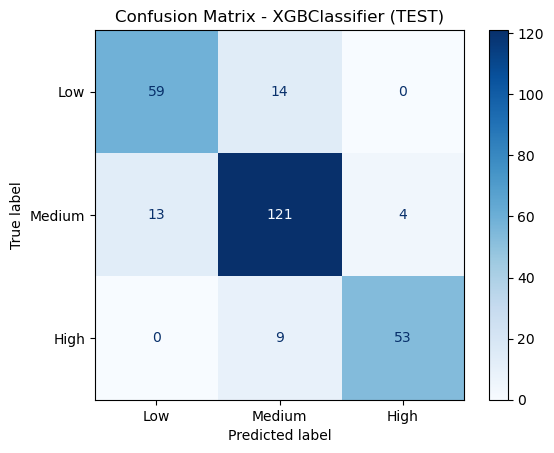

,model,acc_train,acc_test,f1_train,f1_test,f1_macro_train,f1_macro_test,cv_mean,cv_std,train_time_sec
0,RandomForestClassifier,1.0,0.838828,1.0,0.838995,1.0,0.837264,0.844313,0.025650,1.543079
1,XGBClassifier,1.0,0.853480,1.0,0.853697,1.0,0.854235,0.849814,0.022179,4.167396


In [7]:
# Initialize Stratified K-Fold to maintain class proportions during cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_clf = []
cv_clf_scores = {}

# Loop through models to train and evaluate
for name, clf in models_clf.items():
    print(f"\n================ {name} ================")

    # ------------------------
    # Training (Timer)
    # ------------------------
    t0 = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - t0

    # ------------------------
    # Train/Test Predictions
    # ------------------------
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)
    
    # ------------------------
    # Metrics
    # ------------------------
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test, y_pred_test)

    f1_train = f1_score(y_train, y_pred_train, average="weighted")
    f1_test  = f1_score(y_test, y_pred_test, average="weighted")

    f1_macro_train = f1_score(y_train, y_pred_train, average="macro")
    f1_macro_test  = f1_score(y_test, y_pred_test, average="macro")

    print("\n TRAIN")
    print(f"Accuracy      : {acc_train:.4f}")
    print(f"F1-weighted   : {f1_train:.4f}")
    print(f"F1-macro      : {f1_macro_train:.4f}")

    print("\n TEST")
    print(f"Accuracy      : {acc_test:.4f}")
    print(f"F1-weighted   : {f1_test:.4f}")
    print(f"F1-macro      : {f1_macro_test:.4f}")

    # ------------------------
    # CV Robustness (5-fold)
    # ------------------------
    cv_scores = cross_val_score(
        clf, X_train, y_train, cv=kf, scoring="accuracy", n_jobs=-1
    )
    cv_clf_scores[name] = cv_scores

    print(f"\nCV Robustness (Accuracy): mean={cv_scores.mean():.4f} | std={cv_scores.std():.4f}")

    # ------------------------
    # TEST Confusion Matrix
    # ------------------------
    cm = confusion_matrix(y_test, y_pred_test)
    # Note: Ensure the display_labels match the exact order your model predicts
    disp = ConfusionMatrixDisplay(cm, display_labels=["Low", "Medium", "High"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name} (TEST)")
    plt.show()

    # ------------------------
    # Store Results
    # ------------------------
    results_clf.append({
        "model": name,
        "acc_train": acc_train,
        "acc_test": acc_test,
        "f1_train": f1_train,
        "f1_test": f1_test,
        "f1_macro_train": f1_macro_train,
        "f1_macro_test": f1_macro_test,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "train_time_sec": train_time
    })

# Final Results DataFrame
results_clf_df = pd.DataFrame(results_clf)
display(results_clf_df)

## 5. Statistical Comparison 

In [8]:
# Predictions on the test set using previously trained models
y_pred_rf  = models_clf["RandomForestClassifier"].predict(X_test)
y_pred_xgb = models_clf["XGBClassifier"].predict(X_test)

# Boolean arrays for predictions: Correct (1) / Incorrect (0)
rf_correct  = (y_pred_rf  == y_test.values)
xgb_correct = (y_pred_xgb == y_test.values)

# Calculate the 4 quadrants of the contingency table
n11 = np.sum(rf_correct  & xgb_correct)          # RF correct,   XGB correct
n10 = np.sum(rf_correct  & ~xgb_correct)         # RF correct,   XGB incorrect
n01 = np.sum(~rf_correct & xgb_correct)          # RF incorrect, XGB correct
n00 = np.sum(~rf_correct & ~xgb_correct)         # RF incorrect, XGB incorrect

print("Contingency Table (RF rows, XGB columns):")
print(np.array([[n11, n10],
                [n01, n00]]))

# McNemar's test (Chi-square approximation with continuity correction)
num = abs(n01 - n10) - 1
chi2_stat = (num ** 2) / (n01 + n10) if (n01 + n10) > 0 else 0.0
p_value = chi2.sf(chi2_stat, df=1)

print("\n=== McNemar's Test: RF vs. XGB on Test Set ===")
print(f"χ² = {chi2_stat:.4f}, p-value = {p_value:.6f}")

alpha = 0.05
# Interpret the p-value
if p_value < alpha:
    print(" Significant difference detected between the two models (at the 5% level).")
else:
    print(" No significant difference detected.")

Contingency Table (RF rows, XGB columns):
[[218  11]
 [ 15  29]]

=== McNemar's Test: RF vs. XGB on Test Set ===
χ² = 0.3462, p-value = 0.556298
 No significant difference detected.


## 6. Final Comparison & Trade-Off Analysis

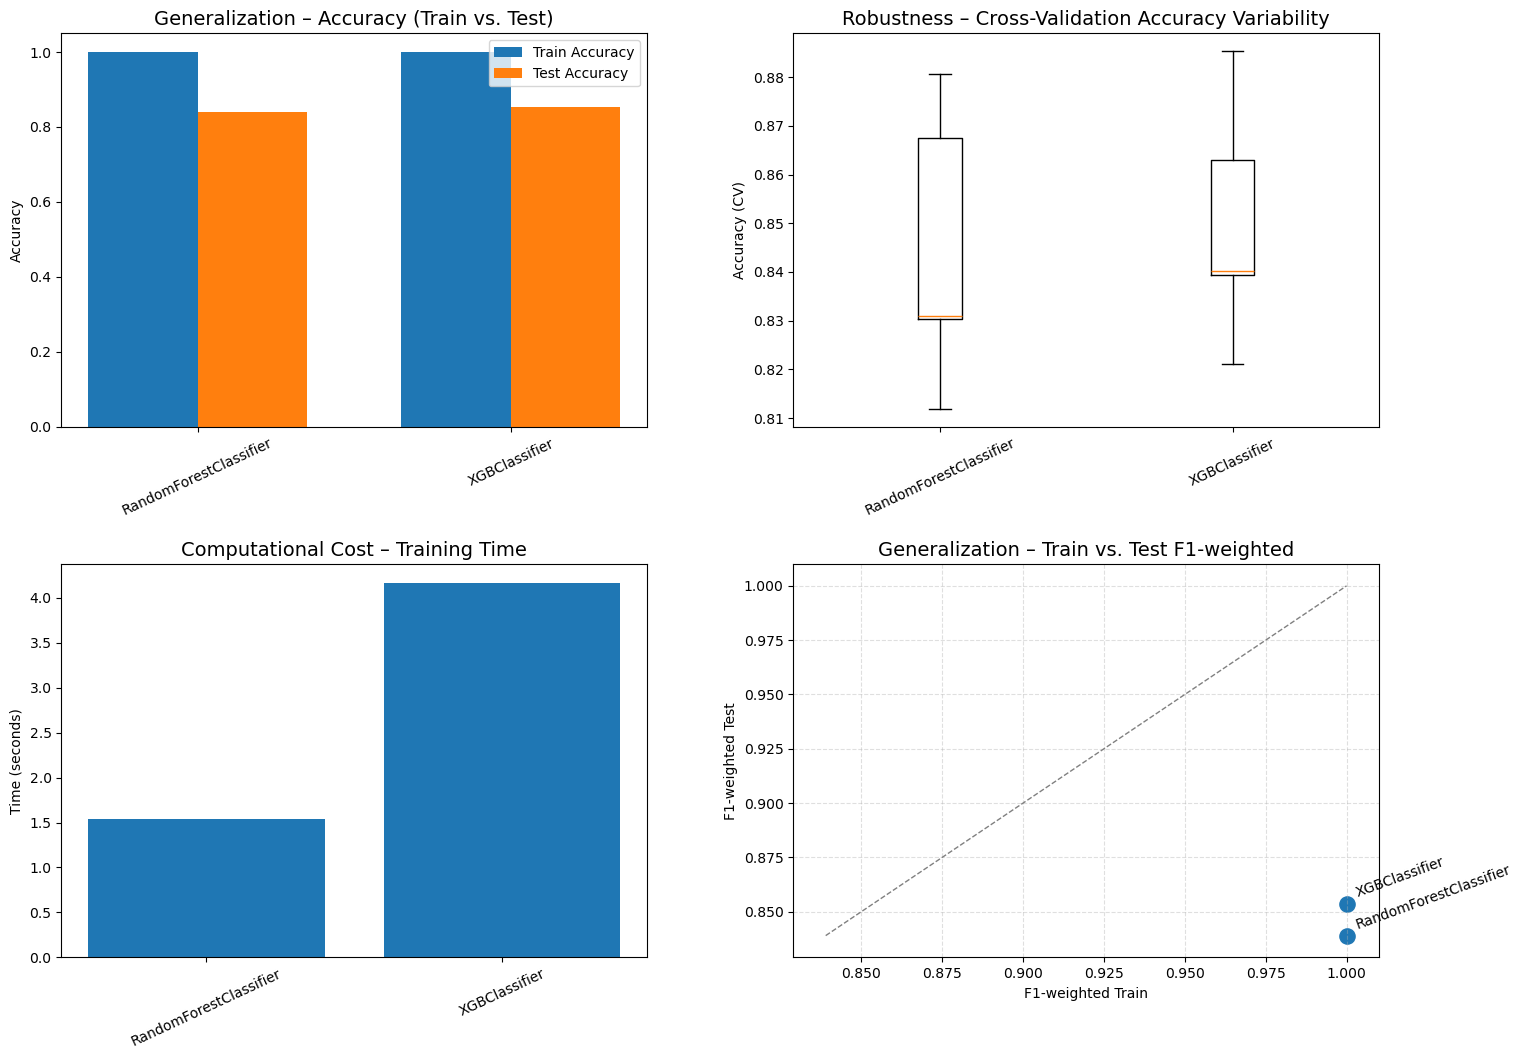

In [9]:
# ==============================================================
# Data Preparation
# ==============================================================

models_list = results_clf_df["model"].tolist()

# Train/Test Accuracy
acc_train_values = results_clf_df["acc_train"].tolist()
acc_test_values  = results_clf_df["acc_test"].tolist()

# Train/Test F1-weighted
f1_train_values = results_clf_df["f1_train"].tolist()
f1_test_values  = results_clf_df["f1_test"].tolist()

# Training time
train_time_values = results_clf_df["train_time_sec"].tolist()

# CV Robustness (Accuracy): dict → list
cv_acc_data = [cv_clf_scores[m] for m in models_list]

# ==============================================================
# Create 2x2 Canvas (Subplots)
# ==============================================================

fig, axes = plt.subplots(2, 2, figsize=(17, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# ==============================================================
# 1️⃣ Plot 1: Train vs. Test Accuracy
# ==============================================================

ax = axes[0, 0]
x = np.arange(len(models_list))
width = 0.35

ax.bar(x - width/2, acc_train_values, width, label='Train Accuracy')
ax.bar(x + width/2, acc_test_values,  width, label='Test Accuracy')

ax.set_title("Generalization – Accuracy (Train vs. Test)", fontsize=14)
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=25)
ax.legend()

# ==============================================================
# 2️⃣ Plot 2: Robustness – CV Accuracy Variability
# ==============================================================

ax = axes[0, 1]

# positions = 1, 2, ..., n_models
positions = np.arange(1, len(models_list) + 1)

ax.boxplot(cv_acc_data, positions=positions, tick_labels=models_list)

ax.set_title("Robustness – Cross-Validation Accuracy Variability", fontsize=14)
ax.set_ylabel("Accuracy (CV)")

# Fix ticks first, then rotate labels
ax.set_xticks(positions)
ax.set_xticklabels(models_list, rotation=25)


# ==============================================================
# 3️⃣ Plot 3: Computational Cost (Training Time)
# ==============================================================

ax = axes[1, 0]
x = np.arange(len(models_list))

ax.bar(x, train_time_values)
ax.set_xticks(x)
ax.set_title("Computational Cost – Training Time", fontsize=14)
ax.set_ylabel("Time (seconds)")

ax.set_xticklabels(models_list, rotation=25)

# ==============================================================
# 4️⃣ Plot 4: Generalization (Train vs. Test F1-weighted)
# ==============================================================

ax = axes[1, 1]

# Scatter Points
ax.scatter(f1_train_values, f1_test_values, s=120)

# Perfect generalization diagonal (y=x)
min_val = min(min(f1_train_values), min(f1_test_values))
max_val = max(max(f1_train_values), max(f1_test_values))
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="gray", linewidth=1)

# Add margins around points for better visibility
margin = 0.01
ax.set_xlim(min_val - margin, max_val + margin)
ax.set_ylim(min_val - margin, max_val + margin)

# Slightly offset model labels for readability
for x, y, label in zip(f1_train_values, f1_test_values, models_list):
    ax.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=(5, 5),
        ha="left",
        rotation=20
    )

ax.set_title("Generalization – Train vs. Test F1-weighted", fontsize=14)
ax.set_xlabel("F1-weighted Train")
ax.set_ylabel("F1-weighted Test")
ax.grid(True, linestyle="--", alpha=0.4)

# ==============================================================
plt.show()

The XGBClassifier outperforms in nearly every evaluation metric, with the only exception being computational cost. It's more robust, generalizable, and delivers superior RMSE and R² scores on the test set.

The additional computational expense translates directly into measurable performance gains. Therefore, if hardware capacity and training time are not significant constraints, XGBClassifier clearly stands out as the optimal choice.